In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Generic 2D Oscillator

The **Generic 2D Oscillator** is The Virtual Brain's flexible planar node: a two-variable system $(V, W)$ whose nullclines are configurable polynomials, so that a single class can be tuned into an excitable, bistable, or oscillatory regime:

$$\dot V = d\,\tau\,(-f V^3 + e V^2 + g V + \alpha W + \gamma(I + V_{inp})),\qquad \dot W = \tfrac{d}{\tau}(a + b V + c V^2 - \beta W).$$

Choosing the polynomial coefficients $a..g$ reproduces FitzHugh-Nagumo-like, bistable, or Morris-Lecar-like dynamics, which is why it is the default workhorse node in many whole-brain studies.

**Reference:** Sanz-Leon, Knock, Spiegler & Jirsa (2015), *Mathematical framework for large-scale brain network modeling in The Virtual Brain*, NeuroImage 111:385-430.

## Build the model

We use an oscillatory configuration and drive it with a constant input to elicit a limit cycle.

In [2]:
node = brainmass.Generic2dOscillatorStep(in_size=1, a=-0.5, b=-10.0, c=0.0,
                                         d=0.1, I=0.0)
node

Generic2dOscillatorStep(
  in_size=(1,),
  out_size=(1,),
  a=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-0.5, dtype=float32)
  ),
  b=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-10., dtype=float32)
  ),
  c=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0., dtype=float32)
  ),
  d=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.1, dtype=float32)
  ),
  e=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(3., dtype=float32)
  ),
  f=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  g=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0., dtype=float32)
  ),
  alpha=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  beta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  gamma=Const(
    fit=False,
    t=IdentityT(),
    reg=

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(300. * u.ms, inputs=lambda i, t: 0.5,
              monitors=['V', 'W'], transient=50. * u.ms)
res['V'].shape

(2500, 1)

## Visualize

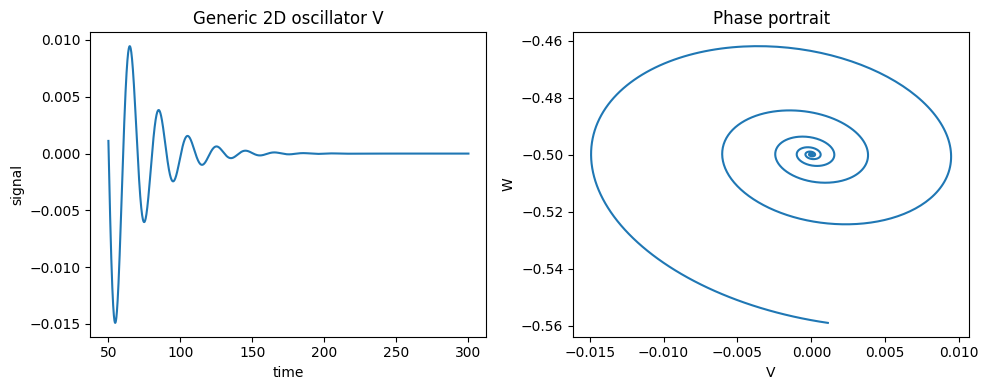

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['V'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Generic 2D oscillator V')
brainmass.viz.plot_phase_portrait(res['V'], res['W'], ax=axes[1])
axes[1].set_xlabel('V'); axes[1].set_ylabel('W')
axes[1].set_title('Phase portrait')
plt.tight_layout()
plt.show()

## Try it: vary the constant input `I`

The constant drive `I` shifts the `V`-nullcline and moves the node between regimes. We sweep it and watch the response amplitude.

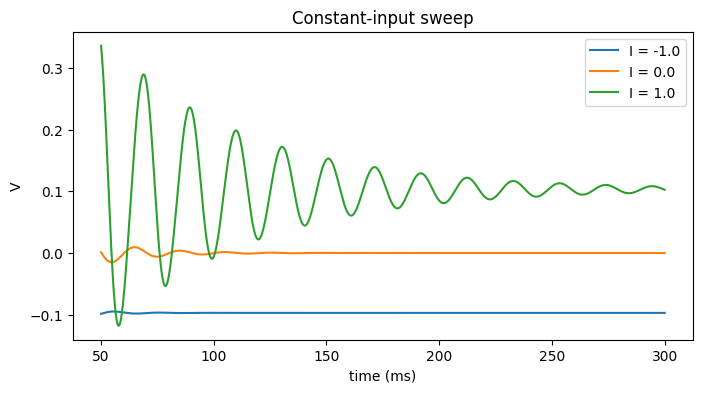

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for I in [-1.0, 0.0, 1.0]:
    m = brainmass.Generic2dOscillatorStep(in_size=1, a=-0.5, b=-10.0, c=0.0, d=0.1, I=I)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        300. * u.ms, inputs=lambda i, t: 0.5, monitors=['V'], transient=50. * u.ms)
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['V'])[:, 0], label=f'I = {I}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('V'); ax.legend()
ax.set_title('Constant-input sweep')
plt.show()